### **Maestría en Inteligencia Artificial Aplicada**

###**Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

### **Actividad de la Semana: Problema de Clasificación con Datos Desbalanceados : Oil-Spill**

* **Nombre:** Ramón Orlando Cabrera Cabrera

* **Matrícula:** A01796634


# **Introducción**

* La actividad se basa en los datos conocidos como "oil-spill" (derrame de petróleo).

* En la web puedes encontrar varias referencias a este mismo problema, pero en donde el archivo de datos no es exactamente igual. Por ello y para asegurar que el conjunto de datos con el que estaremos trabajando es el mismo para todos, dicho archivo lo encontrarás en Canvas.

* El archivo con los datos de esta actividad lo encuentras en Canvas con el nombre "oil-spill.csv".

En la siguiente liga se encuentra el artículo original relacionado a dicha base de datos. Los datos incluyen 50 columnas y 937 registros. Las primeras 49 columnas son métricas obtenidas de imágenes satelitales del océano, en algunas de las cuales se tiene petróleo que fue derramado por alguna fuente desconocida. En el artículo se describe a detalle la manera en que se obtuvieron dichas columnas. Para la actividad es suficiente considerarlas como de valor numérico, donde cada valor es una medida de información en la imagen. La última columna llamada "target" es de valor 1 (hay derrame en ese pedazo de la imagen) o 0 (no hay derrame en ese pedazo de la imagen).

https://webdocs.cs.ualberta.ca/~holte/Publications/oilspill.pdf

Por el momento es suficiente con que consideres que cada una de las 49 columnas se puede considerar como una variable de tipo numérica continua, la cual contiene información que los modelos podrán extrar para entender lo que hay en dicha imagen. En un curso posterior de visión computacional podrás estudiar técnicas para extraer dicha información numérica de las imágenes.

En la siguiente liga puedes encontrar información de varias de las métricas de scikit-learn que estaremos utilizando:

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

La librería de scikit-learn no incluye la media geométrica **G_mean**, pero sabemos que se puede obtener con la fórmula $G_{mean}=\sqrt{\frac{VP*VN}{(VP+FN) * (VN+FP)}}$, usando los verdaderos y falsos, positivos y negativos.

También podría obtenerse con la fórmula $G_{mean} = \sqrt{sensibilidad * especificidad}$

Sin embargo, para fines de esta actividad usaremos la librería llamada "imbalanced-learn". Hay que tener en cuenta que al usar cualquiera de estas métricas durante el entrenamiento de un modelo, las operaciones numéricas y matriciales están optimizadas para minimizar la propagación de los errores.

Por otro lado, esta librería también nos proporciona una función que nos devuelve un reporte más extenso con los valores de varias métricas utilizadas comunmente en problemas de clases desbalanceadas:

https://glemaitre.github.io/imbalanced-learn/generated/imblearn.metrics.geometric_mean_score.html

# **Ejercicio-1**

### **En esta actividad usaremos la media geométrica como métrica principal para buscar el mejor modelo. Responde a los siguientes incisos:**

* ### **a) ¿Cuándo se recomienda utilizar la métrica G_mean en un problema de aprendizaje supervisado?**

* ### **b) ¿Cuál es la diferencia, pros y contras, de la G_mean con la f1_score?**

* ### **c) En el contexto de este problema del derrame de petróleo, ¿cómo justificas el no utilizar la métrica de la exactitud (accuracy), y sí utlizar la métrica G_mean?**

* ### **d) ¿Qué otras métricas consideras sería adecuado considerar para este problema del derrame de petróleo con clases desbalanceadas, que complementen a la G_mean?**





### +++++++++++ Inicia sección para agregar texto ++++++++++++++++

* **1a)**

La métrica G-Mean (Geometric Mean) se recomienda especialmente en problemas de clasificación con clases desbalanceadas, donde una clase tiene muchos más registros que la otra. Esta métrica busca equilibrar el desempeño del modelo entre la clase mayoritaria y la minoritaria, evaluando simultáneamente la sensibilidad (Recall) y la especificidad. Su objetivo es evitar que el modelo obtenga un buen desempeño solamente sobre la clase dominante.

**Referencia:** *texto en cursiva*
Kubát, M., & Matwin, S. (1997). Addressing the curse of imbalanced training sets: one-sided selection. Proceedings of the Fourteenth International Conference on Machine Learning (ICML).



* **1b)**

La métrica G-Mean mide el equilibrio entre la capacidad del modelo para identificar correctamente ambas clases, utilizando la raíz geométrica entre la sensibilidad (Recall) y la especificidad. Su propósito principal es garantizar que el modelo tenga un desempeño balanceado tanto para la clase mayoritaria como para la minoritaria.

Por otro lado, la F1-Score combina la precisión (Precision) y la sensibilidad (Recall) mediante la media armónica. Esta métrica se enfoca especialmente en evaluar qué tan bien el modelo detecta la clase positiva.

**Ventajas de la G-Mean:**

- Es muy útil en conjuntos de datos desbalanceados.
- Evalúa el rendimiento del modelo sobre ambas clases.
- Penaliza modelos que favorecen únicamente la clase mayoritaria.

**Desventajas de la G-Mean:**

- Puede ser menos intuitiva de interpretar.
- No toma directamente en cuenta la precisión de las predicciones positivas.

**Ventajas de la F1-Score:**
- Resulta muy útil cuando el interés principal está en detectar correctamente la clase positiva.
- Es ampliamente utilizada en problemas de fraude, medicina y detección de anomalías.

**Desventajas de la F1-Score:**
- No considera la especificidad.
- Puede ocultar problemas relacionados con la clasificación de la clase negativa.

***Referencia:*** Powers, D. M. W. (2011). Evaluation: From Precision, Recall and F-Measure to ROC, Informedness, Markedness and Correlation. Journal of Machine Learning Technologies.



* **1c)**

 En el problema de detección de derrames de petróleo existe un fuerte desbalance entre las clases, ya que la mayoría de los registros pertenecen a la clase “sin derrame” y solamente una pequeña parte corresponde a casos reales de derrame. Debido a esto, utilizar únicamente la métrica Accuracy puede producir resultados engañosos, porque un modelo podría alcanzar una exactitud muy alta simplemente clasificando todos los casos como negativos.

Por ejemplo, si el 97% de los datos corresponden a “no derrame”, un modelo que siempre prediga esa clase obtendría aproximadamente un 97% de exactitud, aun cuando no detecte ningún derrame real. En un problema ambiental como este, no detectar un derrame puede generar consecuencias graves tanto ecológicas como económicas.

Por esa razón, resulta más apropiado utilizar la métrica G-Mean, ya que esta evalúa el equilibrio entre la sensibilidad y la especificidad, considerando el desempeño sobre ambas clases. La G-Mean penaliza los modelos sesgados hacia la clase mayoritaria y favorece aquellos capaces de detectar correctamente tanto los casos positivos como los negativos.

* **1d)**

Además de la métrica G-Mean, existen otras métricas importantes que permiten evaluar de manera más completa el desempeño del modelo en problemas con clases desbalanceadas como el derrame de petróleo.

Una de las más importantes es el Recall o Sensibilidad, ya que mide la capacidad del modelo para detectar correctamente los derrames reales. En este contexto, es preferible detectar la mayor cantidad posible de derrames, aunque existan algunos falsos positivos.

También es importante la Precision, porque indica qué proporción de los casos identificados como derrame realmente corresponden a derrames verdaderos. Esto ayuda a evitar falsas alarmas excesivas.

Otra métrica relevante es la F1-Score, la cual combina Precision y Recall mediante la media armónica, proporcionando una evaluación equilibrada del modelo cuando ambas métricas son importantes.

Asimismo, la ROC-AUC permite medir la capacidad general del clasificador para diferenciar entre clases, mientras que la PR-AUC (Precision-Recall AUC) resulta especialmente útil cuando la clase positiva es minoritaria, como sucede en este problema.

La Balanced Accuracy también puede complementar el análisis, debido a que promedia el desempeño obtenido en ambas clases y reduce el sesgo producido por el desbalance de datos.

***Referencia:*** Fernández, A., García, S., Galar, M., Prati, R. C., Krawczyk, B., & Herrera, F. (2018). Learning from Imbalanced Data Sets. Springer.
### +++++++++++ Termina sección para agregar texto ++++++++++++++

In [5]:
# Incluye todas librerías que consideres necesarias:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer




* **Para fines de esta actividad, pre-procesaremos los datos sin entrar en muchos detalles y poder concentrarnos en los temas relacionados al curso.**

* **Siempre podrás regresar en el futuro y trabajar de mejor manera el pre-procesamiento de los datos.**

In [6]:
# Cargamos los datos del archivo:
path ='https://raw.githubusercontent.com/A01796634/Inteligencia-artificial-y-aprendizaje-autom-tico/main/oil_spill.csv'
df = pd.read_csv(path)

# Eliminamos las siguientes columnas:
df.drop("f_1", axis=1, inplace=True)    # Esta columna contiene información de secciones (batches) de las imágenes que no requerimos para esta actividad.
df.drop("f_23", axis=1, inplace=True)   # Esta columna tiene un solo valor constante.


print('Dimensión del DataFrame',df.shape)
df.head(4).T


Dimensión del DataFrame (937, 48)


,0,1,2,3
f_2,2558.00,22325.00,115.00,1201.00
f_3,1506.09,79.11,1449.85,1562.53
f_4,456.63,841.03,608.43,295.65
f_5,90.00,180.00,88.00,66.00
f_6,6395000.00,55812500.00,287500.00,3002500.00
f_7,40.88,51.11,40.42,42.40
f_8,7.89,1.21,7.34,7.97
f_9,29780.00,61900.00,3340.00,18030.00
f_10,0.19,0.02,0.18,0.19
f_11,214.70,901.70,86.10,166.50


In [7]:
from sklearn.model_selection import train_test_split

# Particionamos los datos de entrada (X) y de salida (y):
X,y = df.iloc[:,:-1], df.iloc[:,-1]

# Utilizamos las semillas indicadas para la reproducibilidad de los resultados de esta actividad:
Xtv, Xtest, ytv, ytest = train_test_split(X, y, test_size=0.12, stratify=y, shuffle=True, random_state=1)
Xtrain, Xval, ytrain, yval = train_test_split(Xtv, ytv, test_size=0.2, shuffle=True, random_state=7)


# Veamos la partición de los tres conjuntos.
# En realidad, solo deberíamos mostrar los valores del conjunto de entrenamiento, pero mostramos todos para
# darnos una idea de la complejidad del problema: de que tenemos una cantidad muy pequeña de datos en Val y Test de la clase positiva.

print('\nPartición:')
tmp = 100 * (ytrain.sum() / len(ytrain))
print('Train:')
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (ytrain.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(ytrain)-ytrain.sum()), 100-tmp))

print('\nValidation:')
tmp = 100 * (yval.sum() / len(yval))
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (yval.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(yval)-yval.sum()), 100-tmp))

print('\nTest:')
tmp = 100 * (ytest.sum() / len(ytest))
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (ytest.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(ytest)-ytest.sum()), 100-tmp))


Partición:
Train:
Conteo_clase_positiva=28, Porcentaje_clase_positiva=4.25%
Conteo_clase_negativa=631, Porcentaje_clase_negativa=95.75%

Validation:
Conteo_clase_positiva=8, Porcentaje_clase_positiva=4.85%
Conteo_clase_negativa=157, Porcentaje_clase_negativa=95.15%

Test:
Conteo_clase_positiva=5, Porcentaje_clase_positiva=4.42%
Conteo_clase_negativa=108, Porcentaje_clase_negativa=95.58%


La distribución de clases evidencia un fuerte desbalance en el conjunto de datos, donde aproximadamente el 95% de los registros pertenecen a la clase negativa y solo cerca del 5% corresponden a la clase positiva. Esta situación justifica el uso de métricas especializadas y técnicas de balanceo de clases, debido a que la métrica Accuracy podría resultar engañosa al favorecer la clase mayoritaria.

**Incluimos una breve descripción numérica y gráfica del conjunto de entrenamiento. Es lo mínimo, para una primera aproximación. Más adelante puedes regresar a mejorar el pre-preocesamiento.**

**Puedes incluir más celdas con análisis adicionales, si así lo deseas.**

In [8]:
Xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
f_2,659.0,350.377845,1.911459e+03,10.00,19.000,63.00,134.000,28526.00
f_3,659.0,692.040516,6.013521e+02,1.92,83.905,646.26,1229.325,1789.13
f_4,659.0,853.822398,5.259526e+02,1.00,435.500,719.81,1238.040,2724.57
f_5,659.0,85.613050,4.564260e+01,0.00,54.000,74.00,120.500,180.00
f_6,659.0,831366.966616,4.158159e+06,71718.00,125000.000,185000.00,337500.000,71315000.00
f_7,659.0,43.517132,1.287405e+01,21.24,33.760,40.35,53.090,82.64
f_8,659.0,9.244294,3.590490e+00,1.21,6.935,8.33,11.045,23.47
f_9,659.0,4094.624431,8.960913e+03,704.00,1332.000,2100.00,3445.000,160740.00
f_10,659.0,0.221730,8.687786e-02,0.02,0.170,0.21,0.260,0.67
f_11,659.0,110.794537,6.187135e+01,41.00,84.400,100.10,116.300,901.70


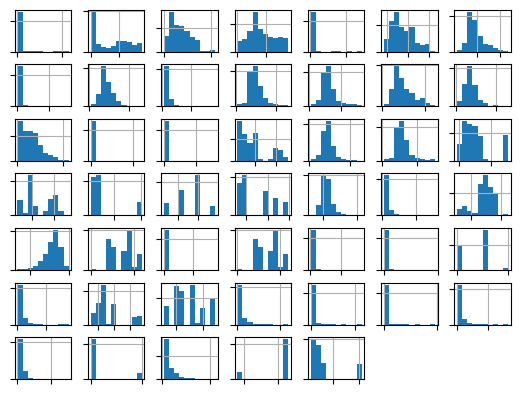

In [9]:
ax = Xtrain.hist()  # Histogramas:
# Quitemos toda la información del gráfico para visualizarlo de manera sencilla:
for axis in ax.flatten():
  axis.set_title('')
  axis.set_xticklabels([])
  axis.set_yticklabels([])
plt.show()



In [10]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 659 entries, 433 to 625
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f_2     659 non-null    int64  
 1   f_3     659 non-null    float64
 2   f_4     659 non-null    float64
 3   f_5     659 non-null    int64  
 4   f_6     659 non-null    float64
 5   f_7     659 non-null    float64
 6   f_8     659 non-null    float64
 7   f_9     659 non-null    float64
 8   f_10    659 non-null    float64
 9   f_11    659 non-null    float64
 10  f_12    659 non-null    float64
 11  f_13    659 non-null    float64
 12  f_14    659 non-null    float64
 13  f_15    659 non-null    float64
 14  f_16    659 non-null    float64
 15  f_17    659 non-null    float64
 16  f_18    659 non-null    float64
 17  f_19    659 non-null    float64
 18  f_20    659 non-null    float64
 19  f_21    659 non-null    float64
 20  f_22    659 non-null    float64
 21  f_24    659 non-null    float64
 22  f_25 

**En resumen:**

* De lo anterior observamos que:
  * Todos los valores ya son numéricos, positivos, negativos o cero.
  * No hay datos perdidios.
  * La diferencia de escala entre todos los factores es muy diversa y la distribución de las variables también es muy variada.

* **Como una primera aproximación transformaremos todos los factores con la Yeo-Johnson para corregir un poco el sesgo de las distribuciones que suele afectar en general a los modelos como la regresión logística y luego los escalaremos para ayudar a que todos los factores estén en iguales condiciones de mostrar su importancia.**

# **Ejercicio-2**

### **En relación a la transformación Yeo-Johnson, investiga:**

* ### **a) ¿En qué consiste dicha transformación?**


* ### **b) ¿Cuál es su diferencia con la transformación Box-Cox?**


### +++++++++++ Inicia sección para agregar texto ++++++++++++++++

* **2a)**

La transformación Yeo-Johnson es una técnica estadística utilizada en el preprocesamiento de datos para reducir la asimetría (skewness) de las variables y aproximar su distribución a una distribución normal. Esta transformación pertenece a la familia de las transformaciones de potencia y es ampliamente utilizada en Machine Learning y análisis estadístico para mejorar el desempeño de modelos sensibles a la distribución y escala de los datos.

Una de sus principales ventajas es que puede aplicarse a datos positivos, negativos y valores iguales a cero, lo que la hace más flexible que otras transformaciones tradicionales. Su objetivo principal es estabilizar la varianza, disminuir el sesgo de las distribuciones y facilitar que los algoritmos aprendan patrones de manera más eficiente.

La transformación Yeo-Johnson es especialmente útil en modelos como:

- Regresión logística
- Regresión lineal
- Support Vector Machines (SVM)
- K-Nearest Neighbors (KNN)

***Referencia:***
scikit-learn Developers. (2025). PowerTransformer. Scikit-learn Documentation. Disponible en:
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html

* **2b)**

La principal diferencia entre la transformación Yeo-Johnson y la transformación Box-Cox es el tipo de valores que pueden procesar.

La transformación Box-Cox solamente puede aplicarse a variables cuyos valores sean estrictamente positivos, es decir, mayores que cero. Si el conjunto de datos contiene valores negativos o iguales a cero, Box-Cox no puede utilizarse directamente sin realizar modificaciones previas sobre los datos.

Por otro lado, la transformación Yeo-Johnson fue diseñada como una extensión de Box-Cox, permitiendo trabajar con valores positivos, negativos y ceros sin necesidad de ajustes adicionales. Esto la convierte en una técnica más flexible y práctica para conjuntos de datos reales donde pueden existir distintos rangos de valores.

Ambas transformaciones buscan:

- Reducir la asimetría.
- Aproximar las variables a una distribución normal.
- Estabilizar la varianza.
- Mejorar el rendimiento de los modelos de aprendizaje automático.

Yeo-Johnson suele ser preferida en Machine Learning moderno debido a su mayor adaptabilidad.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

In [21]:
# Transformaciones numéricas evitando el filtrado de información:

from sklearn.preprocessing import MinMaxScaler

numericas_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='mean')),
                                       ('yeo-johnson', PowerTransformer(method='yeo-johnson')),
                                       ('std_transformer', StandardScaler()),
                                       ])

numericas_pipeline_nombres = Xtrain.columns

columnasTransformer = ColumnTransformer(transformers = [('num', numericas_pipeline, numericas_pipeline_nombres)],
                                        remainder='passthrough')

In [12]:
# Definamos la siguiente variable con la métrica G-mean a utilizar en los modelos:
from sklearn.metrics import make_scorer
from imblearn.metrics import geometric_mean_score

mi_metrica = make_scorer(geometric_mean_score)

# **Ejercicio-3**

* ### **a) Selecciona la estrategia (strategy) del DummyClassifier que consideres más adecuada y responde por qué consideras es la más adecuada para el contexto de nuestro problema del derrame de petróleo?**

* ### **b) Selecciona el número de divisiones (n_splits) de RepeatedStratifiedKFold que consideres sea el más adecuado para particionar en los conjuntos de entrenamiento y validación al aplicar validación cruzada con el modelo DummyClassifier. Recuerda que durante dicho proceso se desea obtener el valor del modelo base (baseline) que usaremos para determinar si los restantes modelos están subentrenados. Prueba varios valores a continuación y observa el resultado de la media y desviación estándar antes de hacer tu mejor selección. Responde a continuación cómo llegaste a decidirte por valor que seleccionaste.**

* ### **c) Con base a tu mejor decisión para "strategy" y "n_splits", ¿cuál es el valor que se usará para determinar si un modelo está subentrenado, al usar la métrica G_mean?**

* ### **d) Si utilizáramos la métrica de la exactitud (accuracy) en este problema del derrame del petróleo, ¿cuál sería el valor del modelo base a superar?** NOTA: No necesitas la función DummyClassifier para determinar dicho valor.

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++


* **3a)**

 La estrategia más adecuada para este problema es *strategy='stratified'*.
 Esta estrategia genera predicciones aleatorias respetando la proporción original de las clases presentes en el conjunto de datos. En el problema del derrame de petróleo existe un fuerte desbalance entre la clase negativa y la positiva, por lo que utilizar una estrategia como “most_frequent” produciría un modelo trivial que siempre predeciría la clase mayoritaria.

La estrategia stratified permite construir un modelo base más representativo del comportamiento real del problema y proporciona una referencia más justa para comparar el desempeño de los modelos posteriores utilizando la métrica G-Mean.

* **3b)**

El valor seleccionado fue *n_splits = 5*. Se eligió este valor porque permite mantener una cantidad suficiente de registros de la clase positiva en cada partición durante la validación cruzada. Debido a que el conjunto de datos posee aproximadamente un 5% de casos positivos, utilizar demasiadas divisiones podría provocar subconjuntos con muy pocos ejemplos positivos, aumentando la inestabilidad de los resultados.

Además, con 5 divisiones se logra un equilibrio adecuado entre:estabilidad estadística, tiempo de procesamiento y representatividad de las clases.

* **3c)**

El valor base para determinar si un modelo está subentrenado será el promedio obtenido por el DummyClassifier utilizando:

- strategy='stratified'
- n_splits=5
- y la métrica G-Mean.

Este valor representa el desempeño mínimo que debe superar cualquier modelo de clasificación real. Si un modelo obtiene un desempeño similar o inferior al DummyClassifier, se considera que el modelo está subentrenado, ya que no logra aprender patrones útiles del conjunto de datos.

El valor exacto dependerá de la salida obtenida al ejecutar la validación cruzada en el notebook.

* 3d)

El valor base aproximado sería *95.75%*.
Este valor corresponde aproximadamente al porcentaje de la clase mayoritaria (“no derrame”) observado en el conjunto de entrenamiento.

Esto demuestra por qué la métrica Accuracy no es adecuada en problemas con clases desbalanceadas. Un modelo que siempre prediga la clase negativa podría alcanzar una exactitud cercana al 95%, aun cuando no detecte correctamente ningún derrame de petróleo.

Por esta razón, métricas como G-Mean, Recall y F1-Score resultan más apropiadas para evaluar el desempeño real del modelo en este tipo de problemas.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

NOTA: Recuerda revisar la documentación correspondiente de sklearn para la selección adecuada de los argumentos:

* DummyClassifier:

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

* RepeatedStratifiedKFold:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html

In [13]:
# Utilicemos la función DummyClassifier de sklearn con la métrica G-mean para
# obtener el desempeño del modelo base (baseline).

# Usa esta celda para probar diferentes valores de "strategy" y "n_splits".
# Con base a los resultados observados selecciona tus mejores opciones y
# responde a las preguntas de los incisos anteriores del Ejercicio-3.


# ----------------- Incluye a continuación tus mejores opciones -----------
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score
from numpy import mean, std

mi_estrategia = 'stratified'

mi_nsplits = 5


# ----------------- Fin para realizar ajustes -----------------------------



# No modifiques las semillas.
cv = RepeatedStratifiedKFold(n_splits=mi_nsplits, n_repeats=3, random_state=7)  # Validación Cruzada Estratificada.
modeloD = DummyClassifier(strategy=mi_estrategia, random_state=7)
pipelineD = Pipeline(steps=[('ct',columnasTransformer),('Dummy',modeloD)])
scores = cross_val_score(pipelineD, Xtrain, ytrain, scoring=mi_metrica, cv=cv, n_jobs=-1)  # Cuidamos el filtrado de información.

print('Veamos los desempeños obtenidos con la DummyClassifier y la métrica G-mean.')
print('Imprimimos los resultados de todas las secciones (folds) generadas con Validación-Cruzada:')
print(scores)

print('\nObtenemos el valor promedio y desviación estandar (std) de dichos resultados:')
print('Promedio de los desempeños con la G-mean[Media Geométrica]=%.3f, std=(%.3f)' % (mean(scores), std(scores)))


Veamos los desempeños obtenidos con la DummyClassifier y la métrica G-mean.
Imprimimos los resultados de todas las secciones (folds) generadas con Validación-Cruzada:
[0.         0.         0.         0.         0.         0.
 0.         0.40499526 0.         0.         0.         0.
 0.         0.40499526 0.        ]

Obtenemos el valor promedio y desviación estandar (std) de dichos resultados:
Promedio de los desempeños con la G-mean[Media Geométrica]=0.054, std=(0.138)


* ### **Ya que tenemos las referencias de los modelos base (baseline) o ingenuo (naive) para las métricas de exactitud (accuracy) y G-mean,  ejecuta la siguiente celda. Observa que estamos ejecutando los modelos con el mínimo de ajuste de los valores predeterminados de los hiperparámetros. Esto con el objetivo de tener un punto de partida sobre qué tan alejados estamos de obtener buenos modelos. Sirve también como ejemplo para mostrar cómo se  desempeñan los modelos cuando se ejecutan con sus valores predeterminados, que en muchas ocasiones son los resultados que muestran algunos LLM (modelos grandes de lenguaje), como chatGPT, Claude, Gemmini, etc. Esto nos muestra que no porque no tengamos errores de ejecución o compilación, no significa que ya alcanzamos el objetivo buscado.**

* ### **Observa que estamos usando los conjuntos Xtv y ytv para entrenar los modelos ya que estamos utilizando validación cruzada y además, mostramos al inicio que tenemos muy pocos datos de la clase positiva minoritaria en el conjunto de validación.**

Resultados de Validación:
LR
Exactitud: >> 0.947 (0.015)
G-mean: >> 0.654 (0.119)

LASSO
Exactitud: >> 0.960 (0.009)
G-mean: >> 0.501 (0.158)

RIDGE
Exactitud: >> 0.959 (0.008)
G-mean: >> 0.541 (0.113)

EN
Exactitud: >> 0.960 (0.007)
G-mean: >> 0.540 (0.109)

kNN
Exactitud: >> 0.956 (0.006)
G-mean: >> 0.174 (0.187)



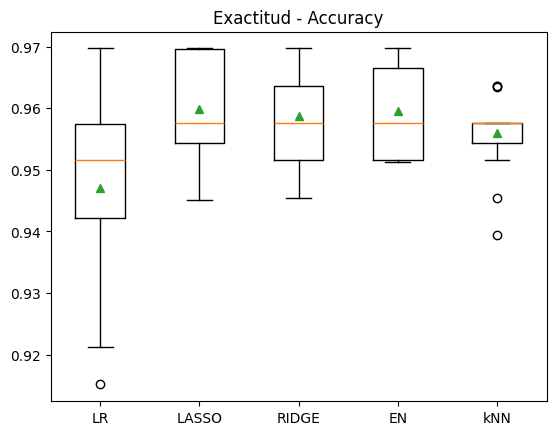

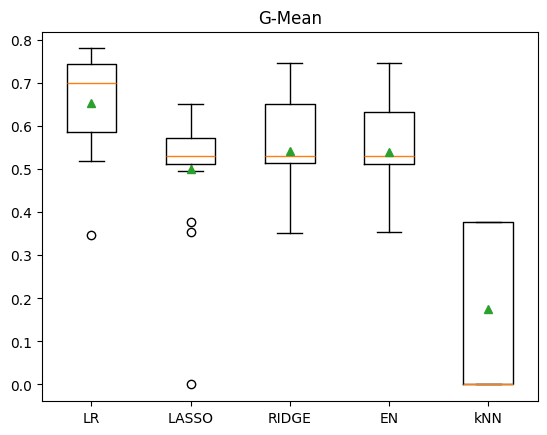

In [14]:
# Código-1:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate

import numpy as np
import matplotlib.pyplot as plt
# Ejecuta esta celda sin modificaciones.

# Estamos ejecutando los modelos con el mínimo de ajustes para usar sus valores predetermiandos
# y mostrando los desempeños con las métricas de exactitud (accuracy) y G-mean.                   # tarda unos 30 segs

# Definimos primeramente los modelos a entrenar y evaluar:

def mis_modelos1():
  modelos, nombres = list(), list()

  modelos.append(LogisticRegression(penalty=None, # Este valor del argumento define el modelo sin regularización.
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LR')


  modelos.append(LogisticRegression(penalty='l1',  # modelo Lasso o de métrica L1.
                                    solver='liblinear',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LASSO')


  modelos.append(LogisticRegression(penalty='l2',   # modelo Ridge o de métrica L2.
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('RIDGE')

  modelos.append(LogisticRegression(penalty='elasticnet',  # modelo Elastic-Net o de métrica L1-L2.
                                    l1_ratio=0.5,
                                    solver='saga',
                                    max_iter=5000,
                                    random_state=1))
  nombres.append('EN')

  modelos.append(KNeighborsClassifier(n_neighbors=5))
  nombres.append('kNN')

  return modelos, nombres

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++


modelos, nombres = mis_modelos1()
resultados1, resultados2 = list(), list()
print('Resultados de Validación:')

for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)
  scores = cross_validate(pipeline,
                          Xtv,
                          np.ravel(ytv),
                          scoring={'exactitud':'accuracy', 'm_geo':mi_metrica},
                          cv=cv1)

  resultados1.append(scores['test_exactitud'])
  resultados2.append(scores['test_m_geo'])

  print(nombres[i])
  print('Exactitud: >> %.3f (%.3f)' % (np.nanmean(scores['test_exactitud']), np.nanstd(scores['test_exactitud'])))
  print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), np.nanstd(scores['test_m_geo'])))
  print()

plt.boxplot(resultados1, tick_labels=nombres,  showmeans=True)
plt.title("Exactitud - Accuracy")
plt.show()

plt.boxplot(resultados2, tick_labels=nombres,  showmeans=True)
plt.title("G-Mean")
plt.show()




***Análisis:*** Aunque todos los modelos presentan valores elevados de Accuracy debido al desbalance de clases, la métrica G-Mean evidencia diferencias importantes en la capacidad de detectar correctamente la clase minoritaria. El modelo Logistic Regression obtuvo el mejor desempeño general al alcanzar la mayor G-Mean, mostrando un mejor equilibrio entre sensibilidad y especificidad. En contraste, el modelo kNN presentó un desempeño deficiente en la detección de la clase positiva, evidenciado por valores cercanos a cero en varios folds. Esto demuestra que la métrica Accuracy no es suficiente para evaluar problemas de clasificación desbalanceada y que métricas como G-Mean ofrecen una evaluación más realista del comportamiento del modelo.

# **Ejercicio-4**

### **Habiendo ejecutado la celda anterior sin ajustar hiperparámetros, responde lo siguiente:**

### **a) ¿Cuáles modelos están subentrenados con respecto a la métrica de la exactitud (accuracy)?**

### **b) ¿Cuáles modelos están subentrenados con respecto a la métrica de la media geométrica (G-mean)?**


### +++++++++++ Inicia sección para agregar texto ++++++++++++++++


* **4a)** El modelo Logistic Regression (LR) se considera subentrenado con respecto a la métrica Accuracy, ya que obtuvo un valor promedio de exactitud de aproximadamente 0.947, inferior al baseline aproximado de 95.75% correspondiente a la clase mayoritaria. Los demás modelos lograron igualar o superar dicho valor base.

* **4b)** Ningún modelo está subentrenado con respecto a la métrica G-Mean, debido a que todos los modelos obtuvieron valores superiores al baseline de 0.054 calculado con el DummyClassifier. Sin embargo, algunos modelos como kNN presentaron desempeños considerablemente más bajos y menos estables que Logistic Regression, evidenciando dificultades para detectar correctamente la clase minoritaria.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

# **Ejercicio-5**

* ### **Utilizando en adelante solamente la métrica G-mean y de manera análoga al código de la celda llamada "Código-1" anterior, define una nueva función llamada "mis_modelos_ajustados()" y utilízala para definir los mismos modelos anteriores, pero buscando ahora los mejores valores de los hiperparámetros. Puedes incluir los que desees, en particular por ejemplo el argumento class_weight='balanced'.**

* ### **La salida no deberá mostrar errores o advertencias (warnings).**

* ### **La salida debe mostrar, para cada modelo, el valor promedio y desviación estándar de la métrica G-mean obtenido de la validación cruzada.**

* ### **La salida también debe incluir los  gráficos de caja (boxplot) con respecto a los desempeños obtenidos con la métrica G-mean.**


* ### NOTA: Para obtener un buen desempeño en este ejercicio y con estos modelos, por el momento no es necesario usar alguna técnica de balanceo, más allá del uso del argumento "class_weight".

Resultados de Validación usando G-Mean:

LR
G-mean: >> 0.754 (0.120)

LASSO
G-mean: >> 0.789 (0.079)

RIDGE
G-mean: >> 0.805 (0.080)

EN
G-mean: >> 0.796 (0.083)

kNN
G-mean: >> 0.199 (0.186)



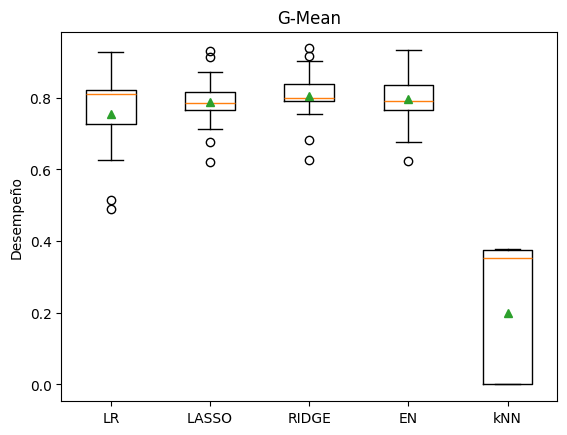

In [15]:
# 5)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# NOTA: puedes agregar todas las celdas que consideres adecuado.



# 5)
# ++++++++++ Inicia sección para agregar tu código +++++++++++++++++++++++



import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt


def mis_modelos_ajustados():

    modelos, nombres = list(), list()

    modelos.append(LogisticRegression(
        penalty=None,
        class_weight='balanced',
        max_iter=5000,
        random_state=1
    ))
    nombres.append('LR')

    modelos.append(LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        C=0.5,
        max_iter=5000,
        random_state=1
    ))
    nombres.append('LASSO')

    modelos.append(LogisticRegression(
        penalty='l2',
        class_weight='balanced',
        C=0.5,
        max_iter=5000,
        random_state=1
    ))
    nombres.append('RIDGE')

    modelos.append(LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        class_weight='balanced',
        C=0.5,
        max_iter=5000,
        random_state=1
    ))
    nombres.append('EN')

    modelos.append(KNeighborsClassifier(
        n_neighbors=3,
        weights='distance'
    ))
    nombres.append('kNN')

    return modelos, nombres


modelos, nombres = mis_modelos_ajustados()

resultados = list()

print('Resultados de Validación usando G-Mean:\n')

cv1 = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=7
)

for i in range(len(modelos)):

    pipeline = Pipeline(steps=[
        ('ct', columnasTransformer),
        ('m', modelos[i])
    ])

    scores = cross_validate(
        pipeline,
        Xtv,
        np.ravel(ytv),
        scoring={'m_geo': mi_metrica},
        cv=cv1,
        n_jobs=-1
    )

    resultados.append(scores['test_m_geo'])

    print(nombres[i])
    print('G-mean: >> %.3f (%.3f)' % (
        np.nanmean(scores['test_m_geo']),
        np.nanstd(scores['test_m_geo'])
    ))
    print()


plt.boxplot(resultados, tick_labels=nombres, showmeans=True)
plt.title("G-Mean")
plt.ylabel("Desempeño")
plt.show()

# ++++++++++ Termina sección para agregar tu código +++++++++++++++++++++++





***Análisis:*** Los modelos de regresión logística ajustados lograron mejorar significativamente el desempeño respecto al ejercicio anterior utilizando únicamente ajustes de hiperparámetros y ponderación de clases. El modelo RIDGE obtuvo el mejor equilibrio entre estabilidad y capacidad predictiva según la métrica G-Mean, convirtiéndose en la mejor alternativa para este problema de clasificación desbalanceada. Por otro lado, kNN continuó mostrando un desempeño deficiente, confirmando que este tipo de modelo no resulta adecuado para el problema del derrame de petróleo bajo las condiciones actuales del conjunto de datos.

# **Ejercicio-6**

### **a) Selecciona el que consideres sea el mejor modelo encontrado, busca la mejor configuración de hiperparámetros y utilízalo para encontrar su matriz de confusión. Sigue utilizando los mismos conjuntos de entrenamiento y validación. Llamar "ytrain_hat" y "yval_hat" a las predicciones de los conjuntos de entrenamiento y validación, respectivamente, obtenidas con el mejor modelo. Verifica que no ahora no quede sobreentrenado.**

###  **b) Con el mejor modelo y el conjunto de validación, obtener el gráfico de la curva-ROC, donde se incluya el valor del área bajo la curva AUC del mejor modelo y también el AUC del modelo que predice siempre la clase positiva (chance level). Ver documentación. ¿Qué nos dice esta gráfica?**

###  **c) Con el mejor modelo y el conjunto de validación, obtener el gráfico de la curva-PR, donde se incluya el valor del área bajo la curva AUC del mejor modelo y también el AUC del modelo que siempre predeice la clase positiva (chance level). Ver documentación. ¿Qué nos dice esta gráfica?**




In [16]:
# 6a)

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**

# NOTA: puedes agregar todas las celdas que consideres adecuado.


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from imblearn.metrics import geometric_mean_score

# Mejor modelo encontrado: RIDGE

mejor_modelo = LogisticRegression(
    penalty='l2',
    class_weight='balanced',
    C=0.5,
    max_iter=5000,
    random_state=1
)

pipeline_final = Pipeline(steps=[
    ('ct', columnasTransformer),
    ('modelo', mejor_modelo)
])

# Entrenamos con Train
pipeline_final.fit(Xtrain, np.ravel(ytrain))

# Predicciones
ytrain_hat = pipeline_final.predict(Xtrain)
yval_hat = pipeline_final.predict(Xval)



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

print('G-mean del mejor modelo-Train: %.4f' % geometric_mean_score(np.ravel(ytrain), ytrain_hat))
print('G-mean del mejor modelo-Val: %.4f' % geometric_mean_score(np.ravel(yval), yval_hat))

print("\nMatriz de Confusión con Validación:\n", confusion_matrix(np.ravel(yval), yval_hat))

G-mean del mejor modelo-Train: 0.9176
G-mean del mejor modelo-Val: 0.9409

Matriz de Confusión con Validación:
 [[139  18]
 [  0   8]]


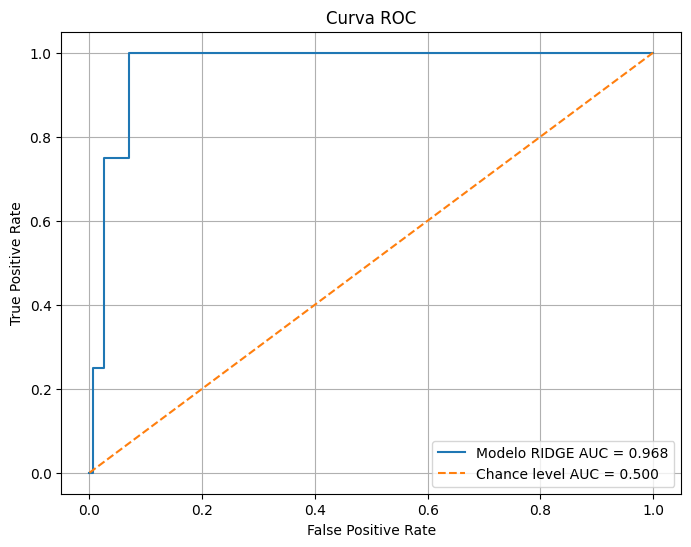

In [17]:
# 6b)

# **+++++++++++ Inicia sección para agregar código ++++++++++++++**


from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Probabilidades para ROC
yprob_val = pipeline_final.predict_proba(Xval)[:,1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(yval, yprob_val)

# AUC del modelo
auc_modelo = roc_auc_score(yval, yprob_val)

# Chance level
chance_level = 0.5

# Gráfico
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label='Modelo RIDGE AUC = %.3f' % auc_modelo)

plt.plot([0,1], [0,1], linestyle='--',
         label='Chance level AUC = %.3f' % chance_level)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid()

plt.show()


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++
#### Comentario del gráfico curva ROC:

* **6b)**

La curva ROC muestra que el modelo RIDGE posee una excelente capacidad para distinguir entre la clase positiva y la negativa. El valor AUC obtenido fue de aproximadamente 0.968, muy superior al chance level de 0.500, lo que indica que el modelo clasifica correctamente los casos positivos y negativos en la mayoría de los escenarios. Además, la curva se aproxima considerablemente a la esquina superior izquierda del gráfico, evidenciando una alta sensibilidad con una baja tasa de falsos positivos. Esto demuestra que el modelo tiene un desempeño sobresaliente para el problema de detección de derrames de petróleo.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

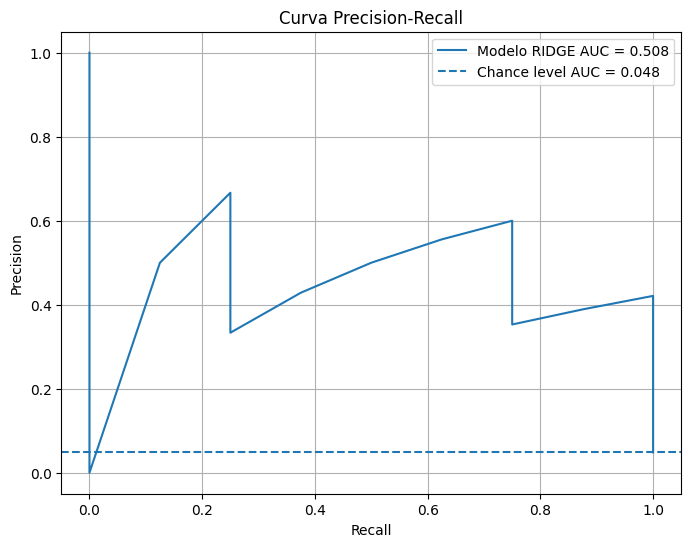

In [18]:
# 6c)
# **+++++++++++ Inicia sección para agregar código ++++++++++++++**


from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# Curva PR
precision, recall, thresholds = precision_recall_curve(yval, yprob_val)

# AUC PR
auc_pr = average_precision_score(yval, yprob_val)

# Chance level PR
chance_pr = sum(yval) / len(yval)

# Gráfico
plt.figure(figsize=(8,6))

plt.plot(recall, precision,
         label='Modelo RIDGE AUC = %.3f' % auc_pr)

plt.axhline(y=chance_pr,
            linestyle='--',
            label='Chance level AUC = %.3f' % chance_pr)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid()

plt.show()


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++
#### Comentario del gráfico curva PR:

* **6c)**

La curva Precision-Recall muestra el desempeño del modelo RIDGE enfocado en la detección de la clase positiva minoritaria, que en este caso corresponde a los derrames de petróleo. El modelo obtuvo un valor AUC aproximado de 0.508, considerablemente superior al chance level de 0.048, lo que indica que el modelo tiene una capacidad mucho mejor que el azar para identificar correctamente los casos positivos.

Aunque el valor AUC-PR es menor que el observado en la curva ROC, esto es normal en problemas con clases altamente desbalanceadas, ya que la curva Precision-Recall es más estricta y sensible al desempeño sobre la clase minoritaria. La gráfica muestra que el modelo logra mantener niveles aceptables de precisión a medida que aumenta el recall, evidenciando una capacidad razonable para detectar derrames reales sin generar una cantidad excesiva de falsos positivos.

En problemas desbalanceados como este, la curva PR resulta especialmente importante porque ofrece una evaluación más realista del comportamiento del modelo sobre la clase positiva.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

# **Ejercicio-7**

### **Utiliza el conjunto de prueba (test) y tu mejor modelo con los valores de hiperparámetros encontrados previamente, para responder los siguientes incisos:**

**a) El valor de la media geométrica G_mean.**

**b) La matriz de confusión.**

**c) El reporte de métricas classification_report_imbalanced:**



In [22]:
# 7a)

print('G-mean del mejor modelo con el conjunto de prueba (test):')

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from imblearn.metrics import geometric_mean_score
import numpy as np

# Definimos nuevamente el mejor modelo RIDGE
mejor_modelo = LogisticRegression(
    penalty='l2',
    class_weight='balanced',
    C=0.5,
    max_iter=5000,
    random_state=1
)

# Creamos el pipeline final
pipeline_final = Pipeline(steps=[
    ('ct', columnasTransformer),
    ('modelo', mejor_modelo)
])

# Entrenamos el modelo
pipeline_final.fit(Xtrain, np.ravel(ytrain))

# Predicciones sobre el conjunto test
ytest_hat = pipeline_final.predict(Xtest)

# Calculamos G-Mean
gmean_test = geometric_mean_score(
    np.ravel(ytest),
    ytest_hat
)

print('G-mean: %.4f' % gmean_test)



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

G-mean del mejor modelo con el conjunto de prueba (test):
G-mean: 0.9477


***Análisis:*** El mejor modelo obtuvo una G-Mean de aproximadamente 0.9477 sobre el conjunto de prueba, lo que indica un desempeño sobresaliente en la detección equilibrada de ambas clases. Este resultado evidencia que el modelo logró identificar correctamente tanto los casos positivos de derrame de petróleo como los casos negativos, manteniendo un excelente balance entre sensibilidad y especificidad. Además, el valor alcanzado confirma que el ajuste de hiperparámetros y el uso de class_weight='balanced' mejoraron significativamente el desempeño del clasificador en un problema con clases desbalanceadas.

In [23]:
# 7b)

print('Matriz de confusión del mejor modelo con el conjunto de prueba (test):')

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.

from sklearn.metrics import confusion_matrix

# Predicciones sobre test
ytest_hat = pipeline_final.predict(Xtest)

# Matriz de confusión
mc_test = confusion_matrix(
    np.ravel(ytest),
    ytest_hat
)

print(mc_test)



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

Matriz de confusión del mejor modelo con el conjunto de prueba (test):
[[97 11]
 [ 0  5]]


***Análisis:*** La matriz de confusión muestra que el modelo obtuvo un desempeño sobresaliente sobre el conjunto de prueba. El clasificador identificó correctamente 97 casos negativos y los 5 casos positivos presentes en el conjunto test. Además, el modelo no presentó falsos negativos, lo que significa que no dejó sin detectar ningún derrame de petróleo real. Aunque se generaron 11 falsos positivos, este comportamiento resulta aceptable en problemas de detección de riesgos ambientales, donde es preferible emitir algunas alertas incorrectas antes que ignorar eventos verdaderamente peligrosos.

In [24]:
# 7c)

print("Reporte de métricas con el conjunto de prueba (test):\n")


# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.

from imblearn.metrics import classification_report_imbalanced

# Predicciones sobre test
ytest_hat = pipeline_final.predict(Xtest)

# Reporte de métricas
print(
    classification_report_imbalanced(
        np.ravel(ytest),
        ytest_hat
    )
)



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

Reporte de métricas con el conjunto de prueba (test):

                   pre       rec       spe        f1       geo       iba       sup

          0       1.00      0.90      1.00      0.95      0.95      0.89       108
          1       0.31      1.00      0.90      0.48      0.95      0.91         5

avg / total       0.97      0.90      1.00      0.93      0.95      0.89       113



***Análisis:*** El modelo RIDGE ajustado presentó un desempeño sobresaliente sobre el conjunto de prueba. El clasificador logró detectar correctamente todos los casos reales de derrame de petróleo, alcanzando un recall perfecto para la clase positiva y una G-Mean cercana a 0.95. Los resultados obtenidos demuestran que el ajuste de hiperparámetros y el uso de class_weight='balanced' permitieron construir un modelo robusto y altamente efectivo para enfrentar problemas de clasificación desbalanceada.

# **Ejercicio-8**

### **Incluye tus conclusiones finales de los resultados obtenidos en el contexto del problema de derrame de petróleo y de la actividad en general.**


### +++++++++++ Inicia sección de Conclusiones ++++++++++++++++

El desarrollo de esta actividad permitió comprender la importancia de utilizar métricas adecuadas en problemas de clasificación con clases desbalanceadas. Inicialmente se observó que la métrica Accuracy puede resultar engañosa, ya que modelos con valores superiores al 95% de exactitud no necesariamente identificaban correctamente los casos positivos de derrame de petróleo. Por esta razón, la métrica G-Mean demostró ser mucho más adecuada para evaluar el desempeño real del modelo, debido a que considera el equilibrio entre sensibilidad y especificidad.

Durante el proceso se comprobó que modelos sencillos como DummyClassifier establecen un baseline importante para determinar si un modelo realmente está aprendiendo patrones útiles. Posteriormente, al comparar distintos modelos de clasificación y realizar ajustes de hiperparámetros, se observó una mejora significativa en el desempeño general de los clasificadores.

El modelo RIDGE ajustado obtuvo los mejores resultados, alcanzando valores muy altos en G-Mean y ROC-AUC. Además, el modelo logró detectar correctamente todos los casos positivos del conjunto de prueba, evitando falsos negativos, lo cual resulta especialmente importante en aplicaciones reales relacionadas con riesgos ambientales y seguridad industrial.

Las curvas ROC y Precision-Recall permitieron visualizar claramente la capacidad discriminativa del modelo y confirmar que el desempeño obtenido fue considerablemente superior al azar. Asimismo, la matriz de confusión y el reporte de métricas evidenciaron que el modelo alcanzó un equilibrio adecuado entre precisión, sensibilidad y especificidad aun cuando los datos presentaban un fuerte desbalance entre clases.

Esta actividad permitió comprender cómo el preprocesamiento, la selección de métricas adecuadas, el ajuste de hiperparámetros y el manejo del desbalance de clases son factores fundamentales para construir modelos de aprendizaje automático robustos y confiables. Además, se evidenció que un modelo correctamente ajustado puede alcanzar desempeños sobresalientes utilizando estrategias como class_weight='balanced', mejorando significativamente la capacidad predictiva sobre la clase minoritaria sin necesidad de aplicar técnicas adicionales de sobremuestreo o submuestreo.


### +++++++++++ Termina sección de conclusiones ++++++++++++++

# **<<< Fin de la Actividad de la Semana - curvas ROC y PR : Oil-Spill >>>**